# Classifying Anonymized Data with K-Nearest Neighbours

We will use k-nearest neighbours (KNN) algorithm to classify anonymized data.

## About the Data

This dataset is completely anonymized and was obtained from [Kaggle](https://www.kaggle.com/datasets/tbyrnes/knn-project-data/data). Since nothing is known about the structure or distribution of the input features, KNN can be a useful model as it is non-parametric and doesn't make any assumptions about the input features or their relationship with the target variable. The KNN algorithm bases its predictions on the distance (i.e., 'similarity') between points in feature space, which is a good starting point for classification tasks involving unknown features.

There are 10 continuous input features and one categorical target variable, all of which have non-descriptive names. The following summarizes the data:

- **XVPM**: continuous input feature
- **GWYH**: continuous input feature
- **TRAT**: continuous input feature
- **TLLZ**: continuous input feature
- **IGGA**: continuous input feature
- **HYKR**: continuous input feature
- **EDFS**: continuous input feature
- **GUUB**: continuous input feature
- **MGJM**: continuous input feature
- **JHZC**: continuous input feature
- **TARGET CLASS**: categorical target variable

## Step 1. Load Packages and Data
We'll start by loading the Python packages that we'll need along with the data.

In [137]:
# math and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

%matplotlib inline

In [6]:
df = pd.read_csv('./data/anonymized_data.csv')

## Step 2. Exploratory Data Analysis

Next, we'll perform Exploratory Data Analysis (EDA) to obtain a deeper understanding of the data. EDA is essential for identifying patterns, outliers, correlations, and potential data quality issues. Our EDA will focus on the following:

- Review basic summary statistics to understand the central tendency and scale of numerical variables
- Check for missing values, invalid entries, or duplicate samples
- Visualize feature distributions to help identify skewed distributions or outliers
- Inspect the target variable's distribution to identify any class imbalance
- Visualize feature distributions by the target variable

### Step 2.1. Basic Summary Statistics
We'll use Panda's `df.info()` function to see a high-level summary of each column and `df.describe()` function to review a summary of basic statistics of the numerical variables.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   XVPM          1000 non-null   float64
 1   GWYH          1000 non-null   float64
 2   TRAT          1000 non-null   float64
 3   TLLZ          1000 non-null   float64
 4   IGGA          1000 non-null   float64
 5   HYKR          1000 non-null   float64
 6   EDFS          1000 non-null   float64
 7   GUUB          1000 non-null   float64
 8   MGJM          1000 non-null   float64
 9   JHZC          1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [12]:
df.describe()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1055.071157,991.851567,1529.373525,495.107156,940.590072,1550.637455,1561.003252,561.346117,1089.067338,1452.521629,0.50000
std,370.980193,392.278890,640.286092,142.789188,345.923136,493.491988,598.608517,247.357552,402.666953,568.132005,0.50025
min,21.170000,21.720000,31.800000,8.450000,17.930000,27.930000,31.960000,13.520000,23.210000,30.890000,0.00000
25%,767.413366,694.859326,1062.600806,401.788135,700.763295,1219.267077,1132.097865,381.704293,801.849802,1059.499689,0.00000
50%,1045.904805,978.355081,1522.507269,500.197421,939.348662,1564.996551,1565.882879,540.420379,1099.087954,1441.554053,0.50000
75%,1326.065178,1275.528770,1991.128626,600.525709,1182.578166,1891.937040,1981.739411,725.762027,1369.923665,1864.405512,1.00000
max,2117.000000,2172.000000,3180.000000,845.000000,1793.000000,2793.000000,3196.000000,1352.000000,2321.000000,3089.000000,1.00000


There are a total of 1,000 data samples with 10 numeric feature columns and 1 categorical column. While all of the input features are numeric and won't need to be encoded, there is a wide range in the central tendency and scale, which suggests that feature scaling will be required, particularly because the KNN model is sensitive to the scale in the data. The `TARGET CLASS` variable is a binary categorical variables stored as integers (0 or 1).

### Step 2.2. Check for Missing Values, Invalid Entries, or Duplicates
Next we look for missing values, invalid entries, and duplicate samples. I'll start by verifying that there are no `null` entries using Pandas' `df.isnull()` function.

In [17]:
df.isnull().sum()

XVPM            0
GWYH            0
TRAT            0
TLLZ            0
IGGA            0
HYKR            0
EDFS            0
GUUB            0
MGJM            0
JHZC            0
TARGET CLASS    0
dtype: int64

Typically I would also look for placeholders like `?`, `na`, and `n/a`, but all of the entries in the data set are either floats or integers so this won't be necessary. 

Next, let's search for duplicate entries using pandas' `df.duplicated()` function.

In [20]:
df.duplicated().sum()

0

### Step 2.3. Visualize Feature Distributions
Now we will visualize the distribution of features, which is a simple yet effective way to identify data quality issues such as skewed distributions, missing data, and outliers.

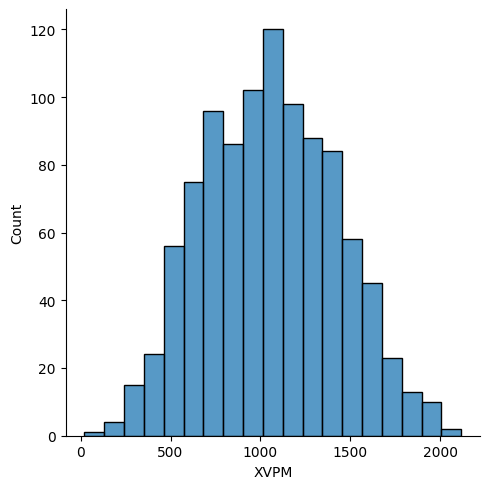

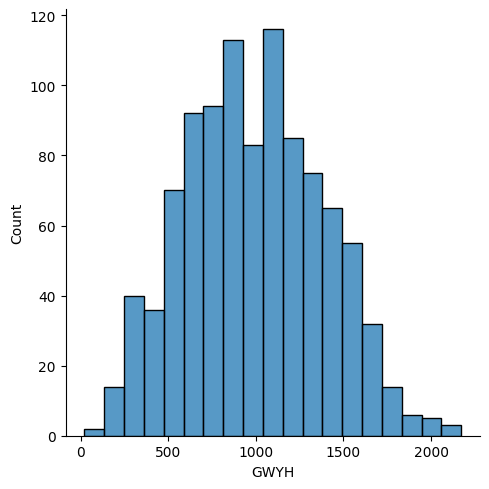

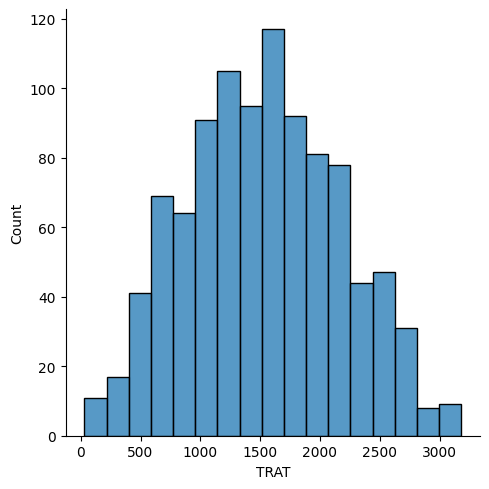

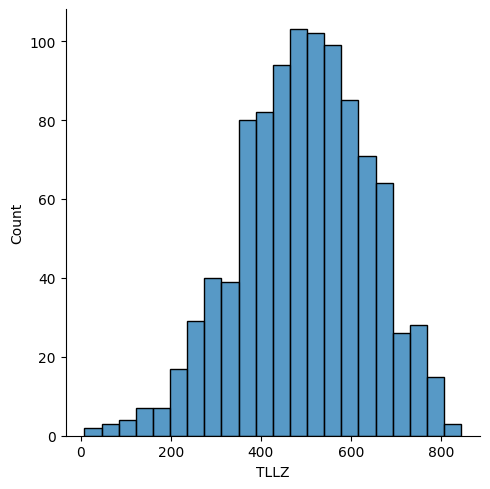

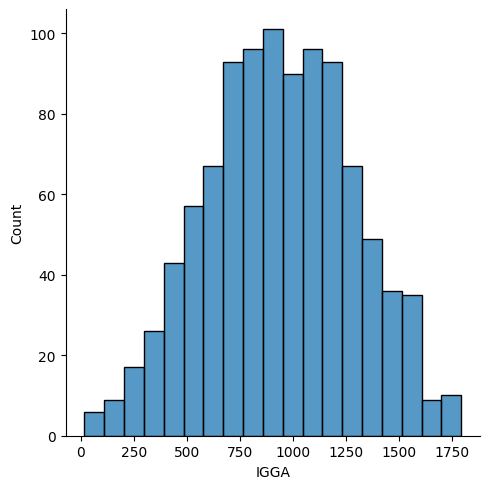

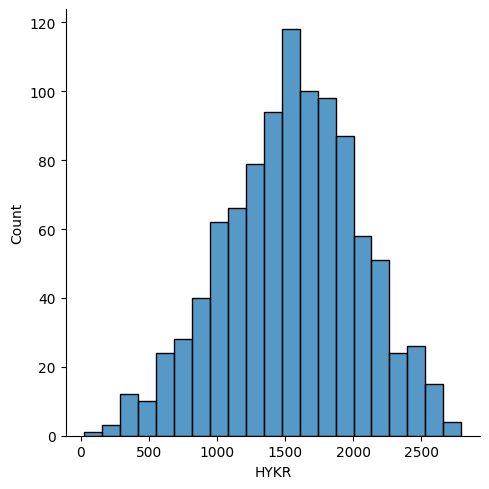

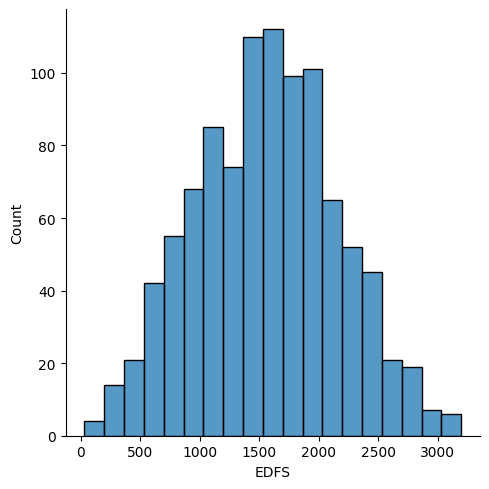

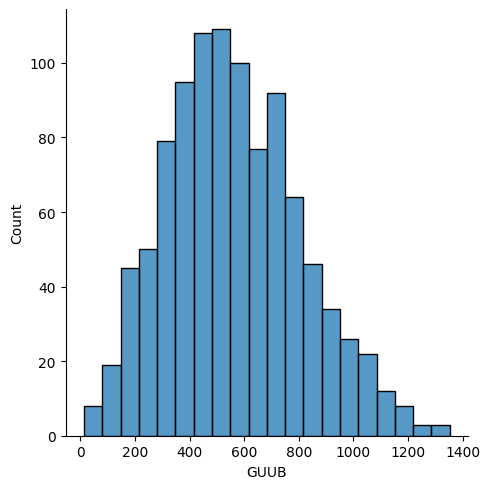

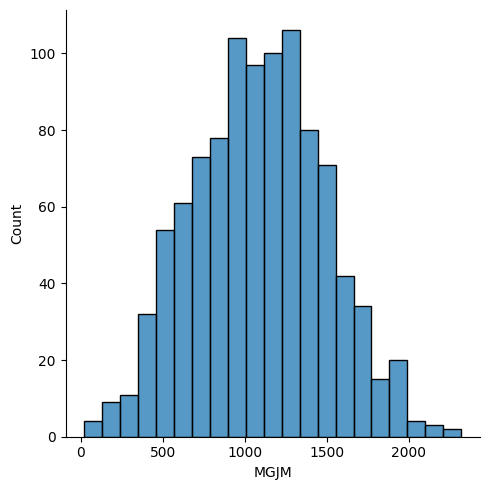

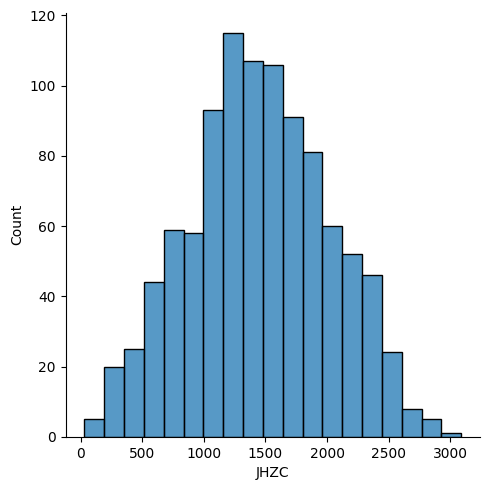

In [23]:
for col in df.drop(columns=['TARGET CLASS']).columns:
    sns.displot(data=df,x=col,kde=False)

These are all relatively simple, well-behaved distributions with no obvious signs of data quality issues.

### Step 2.4. Visualize Target Variable Distribution
Let's now take a look at the distribution of the target variable, `TARGET CLASS`.

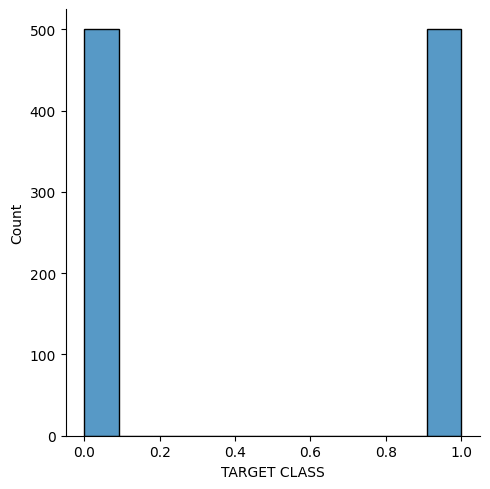

In [25]:
sns.displot(data=df,x='TARGET CLASS',kde=False)

We can see that the target variable is binary (with entries of 0 and 1) and does not have a class imbalance.

### Step 2.5. Visualize Feature Relationships
We'll now visualize the relationships between numerical features using Seaborn's `sns.pairplot()` function, which shows scatterplots between different features on the off-diagonal elements and distributions of each feature along the diagonal elements. Using a colour scheme that differentiates between the two classes can be useful for identifying clusters or regions in the feature space, which can help to indicate how well KNN might perform on this data.

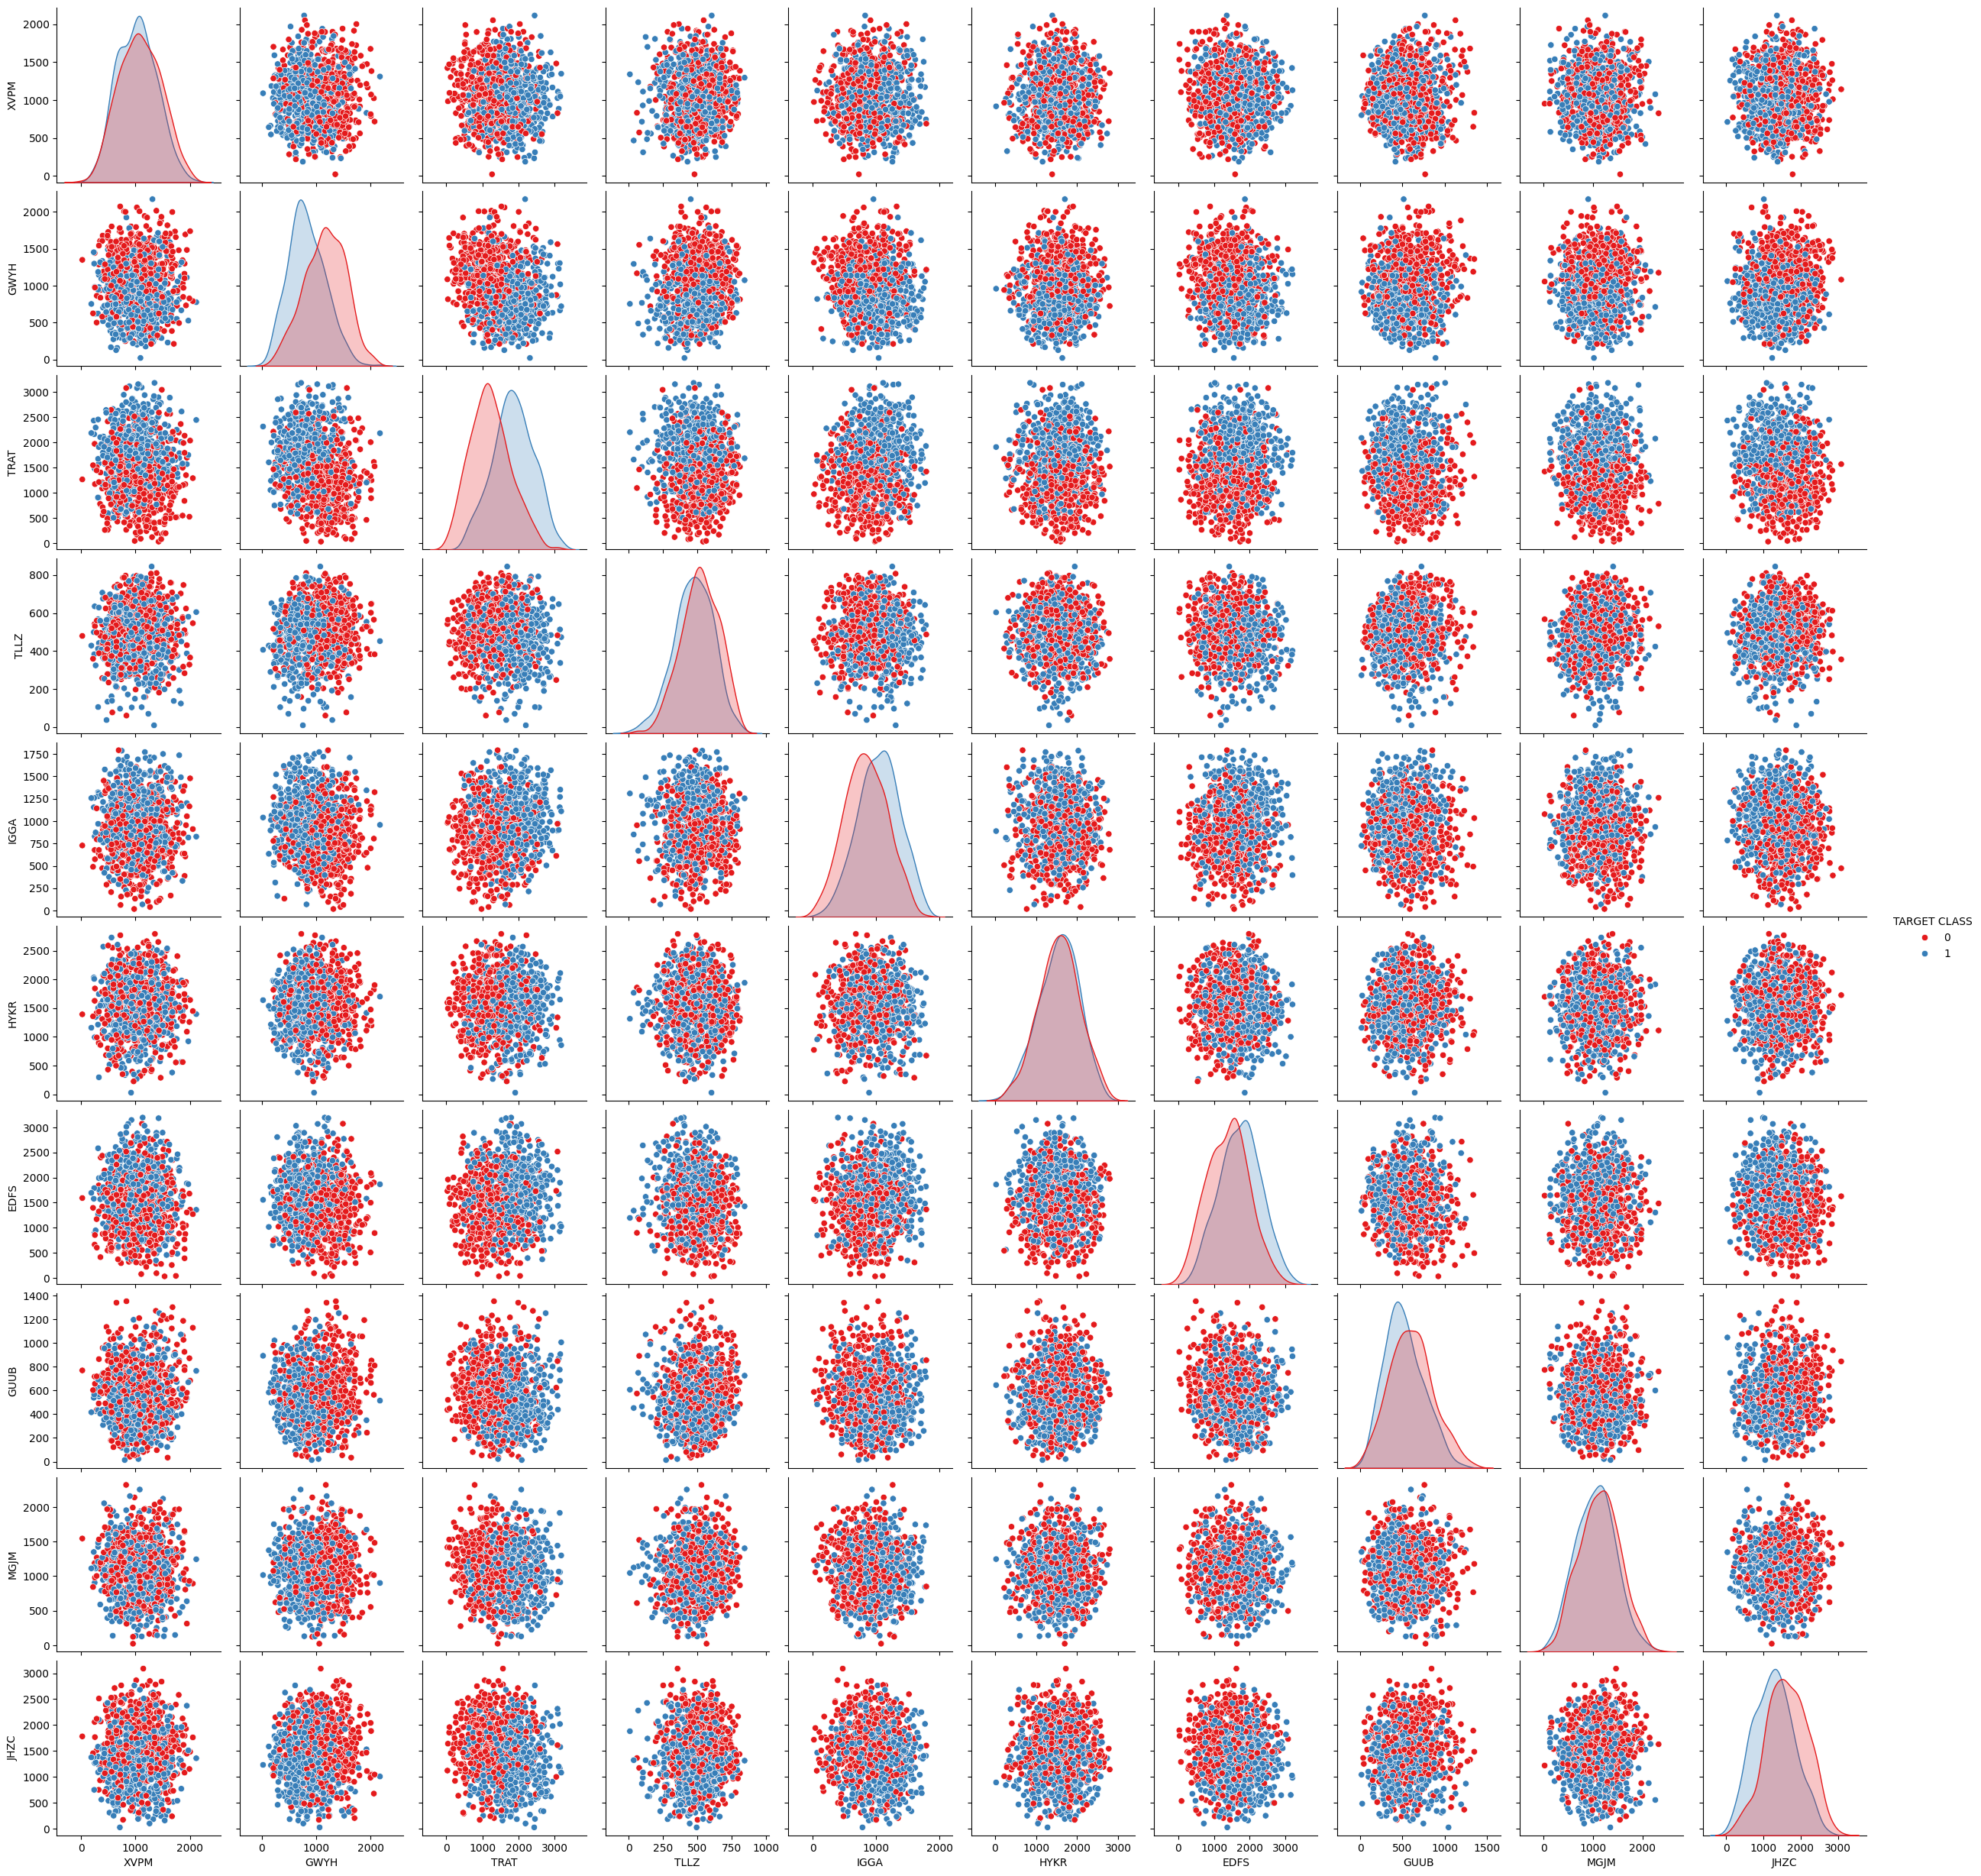

In [29]:
# produce pairplot
sns.pairplot(data=df,hue='TARGET CLASS',palette='Set1')

The results of the pairplot demonstrate that there is varying degrees of class clustering in the feature space. While some feature pairs are relatively well mixed with no strong indication of clustering, other feature pairs have strong clustering that a KNN model will be able to use to identify each class.

## Step 3: Feature Engineering
Our exploratory analysis revealed that the data are relatively simple and well-behaved. While there is no need for encoding since all of the input features are continuous, these features do need to be mapped to a consistent scale. Since KNN uses a distance metric to identify similar data samples in feature space, failing to scale the features can negatively impact its predictions.

### Step 3.1. Feature Scaling
Let's map the continuous features using `scikit-learn`'s `StandardScaler` to ensure that their mean is zero and standard deviation is one.

In [48]:
# define target variable 
target_variable = 'TARGET CLASS'
# define input features that require scaling
features = df.drop(columns=[target_variable]).columns

# scale features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

In [50]:
# preview results
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1.568522,-0.443435,1.619808,-0.958255,-1.128481,0.138336,0.980493,-0.932794,1.008313,-1.069627,0
1,-0.112376,-1.056574,1.741918,-1.504220,0.640009,1.081552,-1.182663,-0.461864,0.258321,-1.041546,1
2,0.660647,-0.436981,0.775793,0.213394,-0.053171,2.030872,-1.240707,1.149298,2.184784,0.342811,1
3,0.011533,0.191324,-1.433473,-0.100053,-1.507223,-1.753632,-1.183561,-0.888557,0.162310,-0.002793,0
4,-0.099059,0.820815,-0.904346,1.609015,-0.282065,-0.365099,-1.095644,0.391419,-1.365603,0.787762,0


## Step 4: Correlation Analysis
KNN is not particularly sensitive to multicollinearity in the way that linear models like linear regression and logistic regression are because it makes predictions based on distances between data samples in feature space rather than feature coefficients. However, it is still worth exploring whether there are redundant features. For this, we will explore the correlations between input features by building a correlation matrix using `panda`'s `.corr()` function and identifying cases where the Pearson correlation coefficient indicates a strong correlation ($|r|>0.8$).

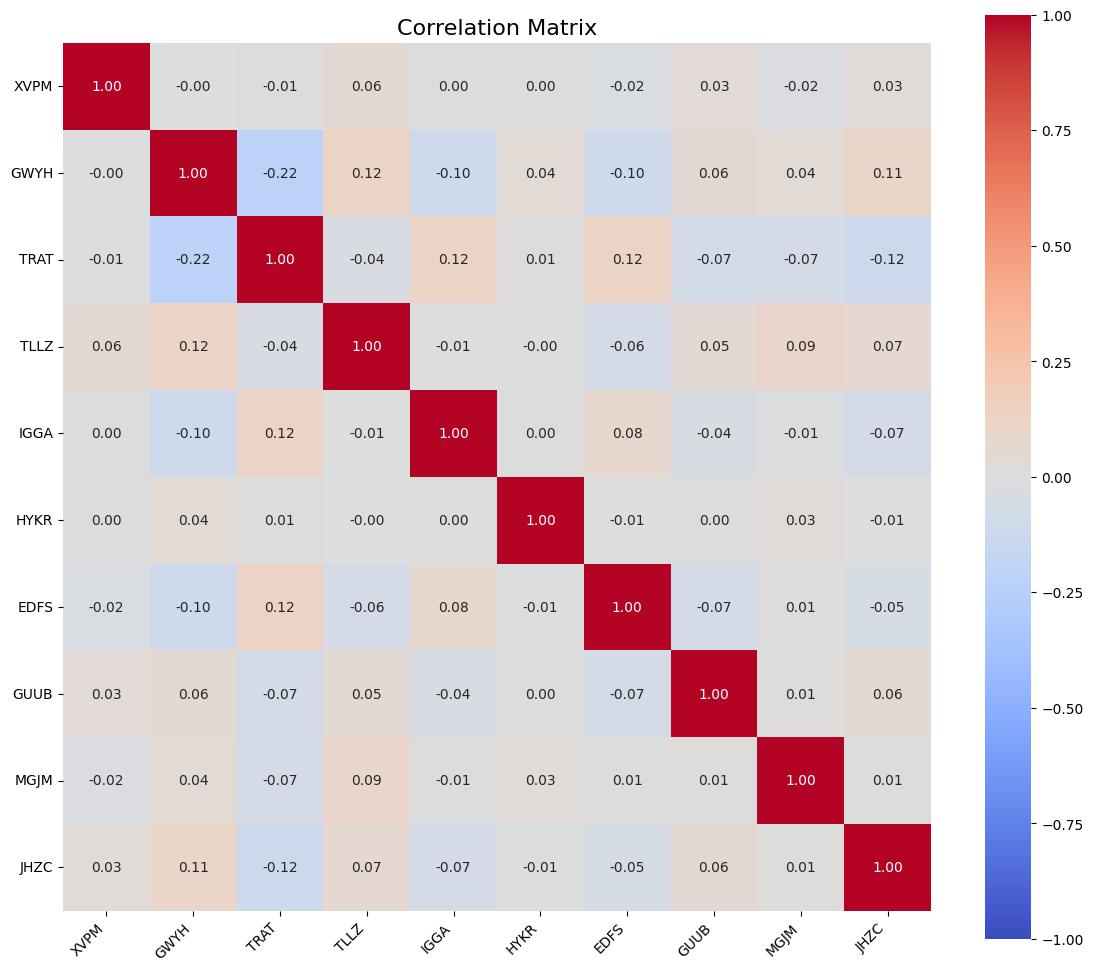

Pairs of correlated features: []


In [52]:
corr_matrix = df[features].corr()

# correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",annot_kws={"size": 10},cmap="coolwarm",vmin=-1,vmax=1,square=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

corr_feature_pairs = []
# iterate through indices of upper-right triangle
# of correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        # correlated pairs if |r|>0.8
        if abs(r) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_feature_pairs.append((col1,col2))

print("Pairs of correlated features:", corr_feature_pairs)

This demonstrates that there are no strong correlations between input feature pairs.

## Step 5. KNN Modelling
Our data have been cleaned and pre-processed so it's time to train a KNN model!

### Step 5.1. Train Test Split
I'll follow the standard process of separating the input features (`X`) from the target variable (`y`) and splitting the data into training (`_train`) and testing (`_test`) sets using `scikit-learn`'s `train_test_split()` function. Splitting the data into training and testing sets allows us to evaluate the model performance using an independent data set that the model hasn't seen during its training phase. This is an essential step for determining how well the model generalizes to unseen data.

In [62]:
# separate input features from target variable
X = df[features]
y = df[target_variable]

# split the data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 5.2. Train the KNN Model
Let's now train the KNN model using `scikit-learn`'s `KNeighborsClassifier()` function! By default, this function assumes that $k=5$, which I will make clear using the `n_neighbors` variable.

In [74]:
# train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

### Step 5.3. Make Predictions on the Test Set
With the KNN model trained, let's make predictions and take a look at the distribution of the predicted class labels.

In [79]:
# predict the target variable
y_predict = knn.predict(X_test)

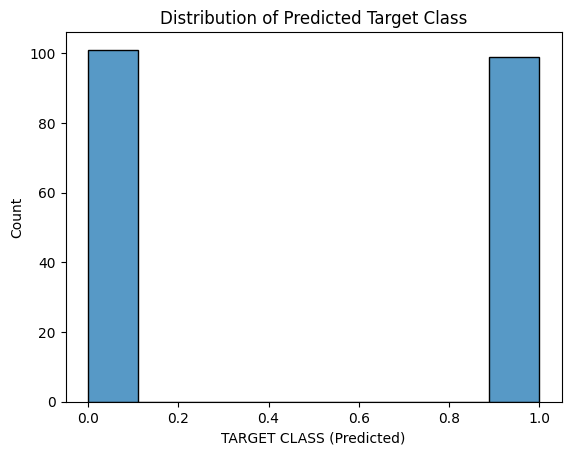

In [86]:
# plot distribution
sns.histplot(y_predict)
plt.xlabel('TARGET CLASS (Predicted)')
plt.ylabel('Count')
plt.title('Distribution of Predicted Target Class')
plt.show()

It looks like the predicted class labels are relatively balanced, with a slightly higher number of negative predictions (`=0`) than positive predictions (`=1`).

### Step 5.4. Test Model Performance

We will now test the model performance to get a better understanding of how well the KNN model performs on unseen data.

#### Step 5.4.1. Confusion Matrix

The confusion matrix is a diagnostic tool used to evaluate the performance of a classification model by summarizing how the predicted class labels compare to the actual class labels. For binary classification, the confusion matrix is a 2x2 matrix where the elements along the diagonal represent the true negative (TN) and true positive (TP) class labels (i.e., correct labels), while the off-diagonal elements represent the false negative (FN) and false positive (FP) class labels (i.e., incorrect labels). This simple structure demonstrates whether the model is able to properly separate positive and negative class labels, and whether there is any confusion between them.

It is worth noting that different sources use different conventions for the confusion matrix; `scikit-learn` uses the following convention: "...the count of true negatives is [0,0], false negatives is [1,0], true positives is [1,1] and false positives is [0,1]." Knowing this allows us to calculate two additional metrics that aren't included in the classification report (next step): the false positive rate (FPR) and false negative rate (FNR).

[[82 18]
 [19 81]]


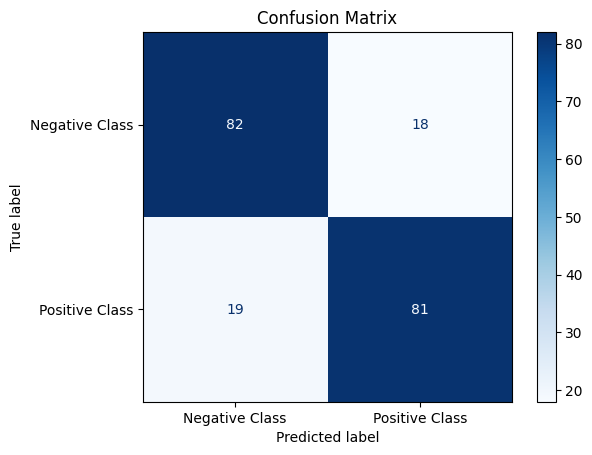

The FPR is 18.0% and the FNR is 19.0%.


In [97]:
# compute confusion matrix
cm = confusion_matrix(y_test,y_predict)
print(cm)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# define entries of confusion matrix
TN = cm[0,0]
FN = cm[1,0]
TP = cm[1,1]
FP = cm [0,1]

# calculate the FPR and FNR
FPR = FP/(FP+TN)
FNR = FN/(FN+TP)
print(f"The FPR is {FPR*100:.1f}% and the FNR is {FNR*100:.1f}%.")

The confusion matrix for this KNN model reveals a relatively high FPR (18%) and FNR (19%). While the model correctly identifies most cases, these errors are quite high. This is likely because we used the default number of neighbours used in the model ($k=5$), which has not yet been tuned for optimial model performance.

#### Step 5.4.2. Classification Report
The classification report is another common diagnostic tool used to evaluate the performance of a classification model, which summarizes four key metrics: precision, recall, f1-score, and support.

Precision quantifies how well you can trust a positive prediction, measured as the proportion of positive predictions that were correct:

$$
\begin{aligned}
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}.
\end{aligned}
$$

The recall is complementary to precision, which quantifies the coverage of true positives measured as the proportion of true positives that were identified:

$$
\begin{aligned}
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}.
\end{aligned}
$$

The F1-score is the harmonic mean of precision and recall, which offers a more balanced metric and can be particularly useful when there is a class imbalance:

$$
\begin{aligned}
\text{F1-score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}.
\end{aligned}
$$

Lastly, support is the total number of occurrences in each class label and can help to provide context for the above key metrics, particularly in the case of a class imbalance.

In [102]:
# compute classification report
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       100
           1       0.82      0.81      0.81       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



The classification report demonstrates a strong performance of the KNN model, with an average precision of 82% and an average recall and f1-score of 81%. This means that the model has a strong coverage of positive cases (recall) and a high accuracy when predicting positive cases (precision). The test set copntains a perfectly balanced distribution of class labels, in contrast to the slight imbalance in the predicted class labels. 

#### Step 5.4.3. Choosing an Optimal K Value
To optimize the chosen number of neighbours ($k$), we will plot the error rate over a range in $k$. The "elbow method" identifies the value of $k$ where the error rate starts to level off (i.e., the 'elbow' of the curve), balancing the risk of over-fitting at low $k$ values and under-fitting at high $k$ values.

To calculate the error rate, we first need to know the accuracy, which quantifies the overall proportion of correct predictions

$$
\begin{aligned}
\text{Accuracy} = \frac{\text{TN + TP}}{\text{TNR + FPR + TPR + FPR}},
\end{aligned}
$$

which we can compute using `scikit-learn`'s `accuracy_score()` function. The error rate will then be given by:

$$
\begin{aligned}
\text{Error rate} = (1 - \text{Accuracy}).
\end{aligned}
$$


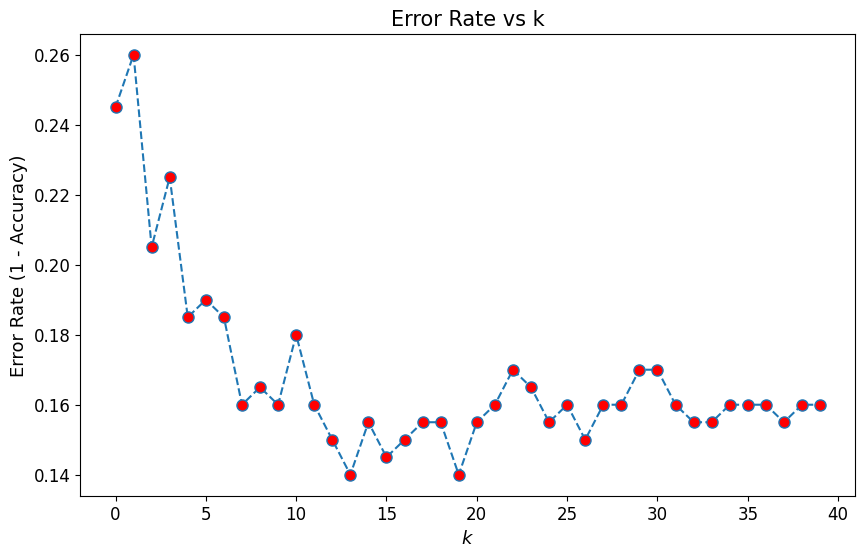

In [164]:
error_rate = []

for k in range(1,41):
    # train the KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    # predict the target variable
    y_predict = knn.predict(X_test)

    # compute accuracy
    accuracy_k = accuracy_score(y_test,y_predict)

    # compute error rate and append
    error_rate_k = (1-accuracy_k)
    error_rate.append(error_rate_k)

# transform list to array
error_rate = np.array(error_rate)

# plot error rate vs k
plt.figure(figsize=(10,6))
plt.plot(np.arange(40),error_rate,ls='--',color='tab:blue',marker='o',markerfacecolor='red',markersize=8)
plt.xlabel(f"$k$",fontsize=13)
plt.ylabel("Error Rate (1 - Accuracy)",fontsize=13)
plt.title("Error Rate vs k",fontsize=15)
plt.tick_params(axis='both', labelsize=12)
plt.savefig("./figures/error_vs_k.png",bbox_inches="tight")
plt.show()

The error rate versus $k$ shows the classic pattern of rapidly decreasing error with increasing $k$, which then levels off. The error rate has a local minimum at $k=13$ beyond which the error rate doesn't change much. Therefore, $k=13$ will be chosen as the optimal value. Not only does this minimize the error rate, but balances the risk of over fitting with small $k$ values and under fitting with large $k$ values.

#### Step 5.4.4. Re-Training an Optimized KNN Model
Having identified the value of $k$ that minimizes the error rate, we will now re-train the optimized KNN model.

In [178]:
# train the optimized KNN model
k = 13
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train,y_train)

# predict the target variable
y_predict_optimized = knn.predict(X_test)

Let's now verify the performance of our optimized KNN model.

[[82 18]
 [19 81]]


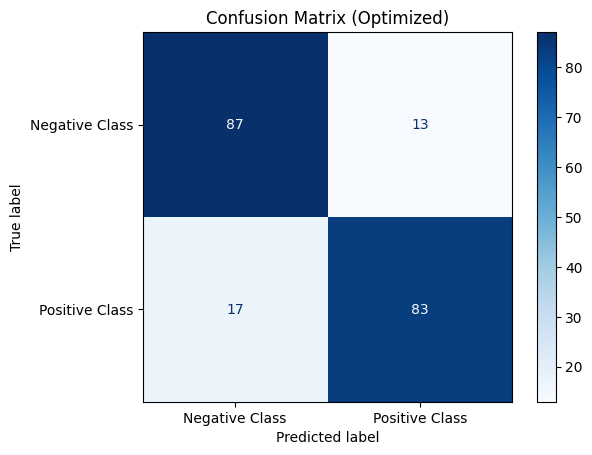

The optimized FPR is 13.0% (from 18.0%) and the optimized FNR is 17.0% (from 19.0%).


In [189]:
# compute confusion matrix
cm_optimized = confusion_matrix(y_test,y_predict_optimized)
print(cm)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimized, display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Optimized)')
plt.show()

# define entries of confusion matrix
TN = cm_optimized[0,0]
FN = cm_optimized[1,0]
TP = cm_optimized[1,1]
FP = cm_optimized [0,1]

# calculate the FPR and FNR
FPR_optimized = FP/(FP+TN)
FNR_optimized = FN/(FN+TP)
print(f"The optimized FPR is {FPR_optimized*100:.1f}% (from {FPR*100:.1f}%) and the optimized FNR is {FNR_optimized*100:.1f}% (from {FNR*100:.1f}%).")

In [187]:
# compute classification report
print(classification_report(y_test,y_predict_optimized))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       100
           1       0.86      0.83      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



Optimizing the value of $k$ demonstrated noticeable improvements in the KNN model's performance. The FPR was reduced by 5% and the FNR was reduced by 2%. In addition to this, the average precision was increased by 3% while both the average recall and f1-score were increased by 4%. 

## Step 6. Summary
This demonstrates the end-to-end process of building a KNN model to classify a completely anonymized data set. The data have 1,000 data samples with 10 continuous input features and one categorical target variable (`TARGET CLASS`).

This was a relatively simple data set in that the input features were all continuous with simple distributions and no obvious signs of data quality issues. As KNN uses a distance metric to identify similar data samples in feature space, feature scaling was used to map the continuous features to have a mean of zero and standard deviation of one. A correlation analysis was used to identify multicollinearity, however, no feature pairs were found to be strongly correlated (defined by those having a Pearson correlation coefficient of $|r|>0.8$).

The initial KNN model using the default $k=5$ performed moderately well, achieving an average precision of 82% along with an average recall and f1-score of 81%. On the test set of 200 samples, the FPR was 18% and the FNR was 19%, demonstrating room for improvement.

Using the elbow method, an optimal value of $k=13$ was identified. This increased the model's performance across the board:. the FPR was reduced by 5%, the FNR was reduced by 2%, the average precision was increased by 3%, and both the average recall and f1-score were increased by 4%. 